# Demand Forecasting Project: Store-Item Daily Sales Forecasting

## Business Context
A business needs to predict future demand so it can:
- plan inventory,
- reduce waste,
- allocate operations capacity,
- improve customer experience,
- support business planning.

## Dataset
Use the Kaggle dataset: **Store Item Demand Forecasting Challenge**.

https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data



## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Datasets/demand-forecasting/data/train.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store", "item", "date"]).reset_index(drop=True)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Stores:", df["store"].nunique())
print("Items:", df["item"].nunique())

Rows: 913000
Columns: 4
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Stores: 10
Items: 50


## 3. Problem Statement

### Business Problem
A business platform wants to forecast **daily demand for each item at each store**.


### ML Problem
Predict: item sales

using historical sales patterns and date-based features.


### Why this matters
If demand is predicted well, the business can:
- stock the right amount of products,
- reduce out-of-stock issues,
- reduce overstock waste,
- schedule staff or delivery capacity better.

## 4. Basic Data Quality Checks

In [ ]:
df.isna().sum()

,0
date,0
store,0
item,0
sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


## 5. Exploratory Data Analysis - EDA

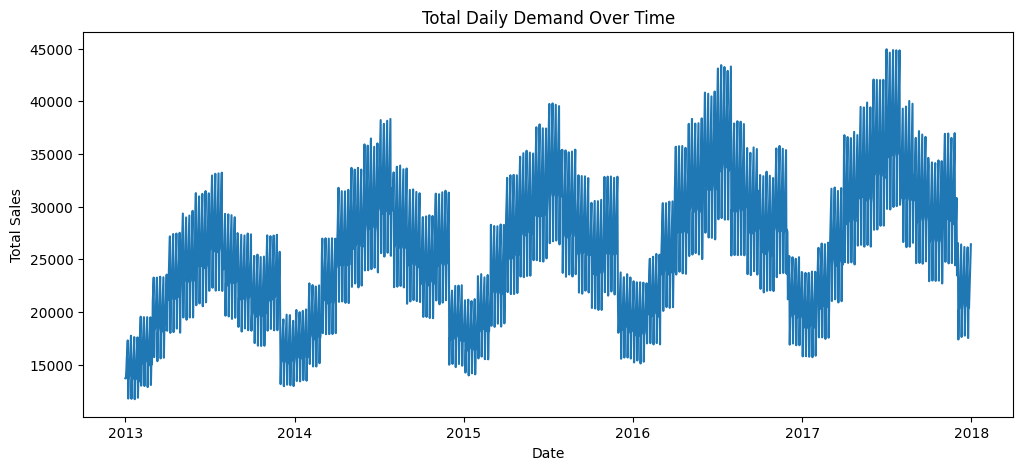

In [ ]:
daily_sales = df.groupby("date", as_index=False)["sales"].sum()

plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

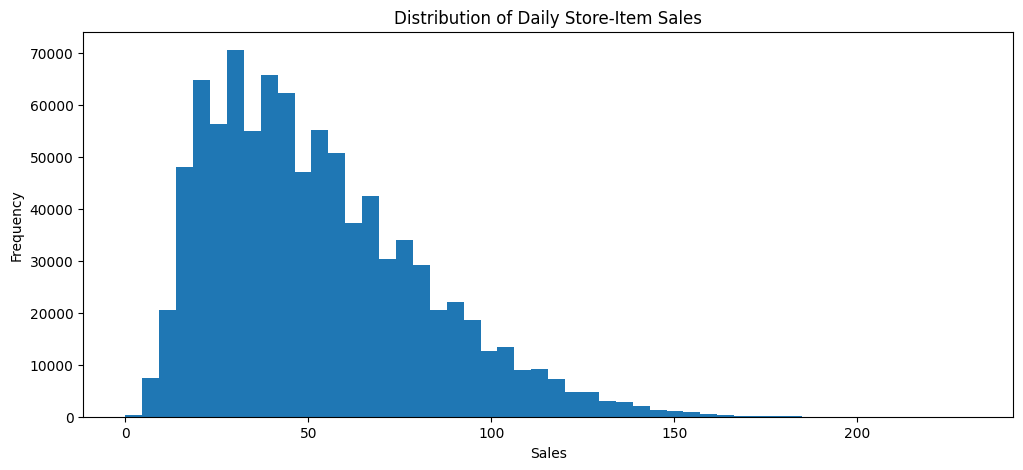

In [ ]:
plt.hist(df["sales"], bins=50)
plt.title("Distribution of Daily Store-Item Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

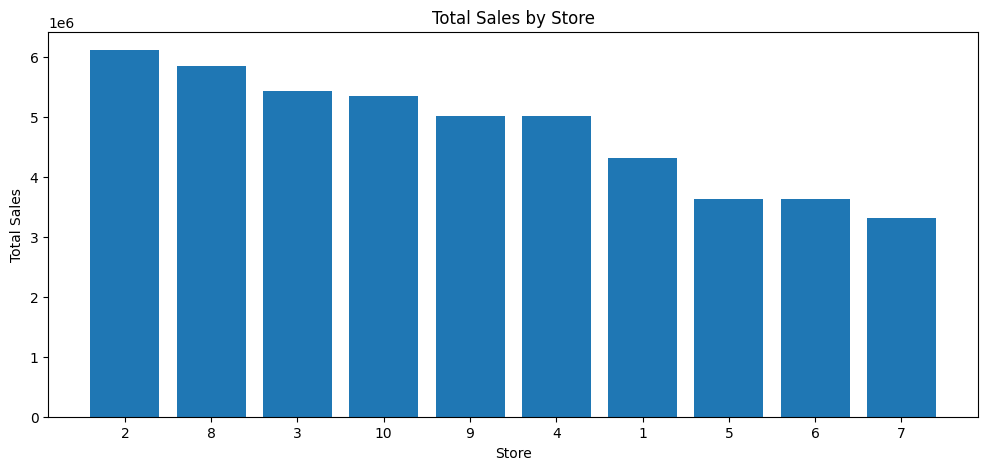

,store,sales
1,2,6120128
7,8,5856169
2,3,5435144
9,10,5360158
8,9,5025976


In [ ]:
store_sales = df.groupby("store", as_index=False)["sales"].sum().sort_values("sales", ascending=False)

plt.bar(store_sales["store"].astype(str), store_sales["sales"])
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

store_sales.head()

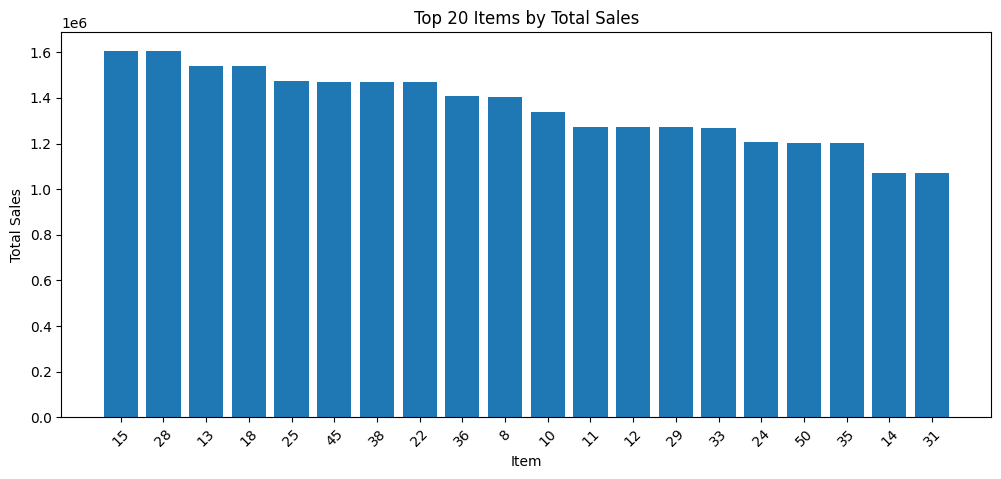

,item,sales
14,15,1607442
27,28,1604713
12,13,1539621
17,18,1538876
24,25,1473334
44,45,1471467
37,38,1470330
21,22,1469971
35,36,1406548
7,8,1405108


In [ ]:
item_sales = df.groupby("item", as_index=False)["sales"].sum().sort_values("sales", ascending=False)

plt.bar(item_sales["item"].astype(str).head(20), item_sales["sales"].head(20))
plt.title("Top 20 Items by Total Sales")
plt.xlabel("Item")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

item_sales.head(10)

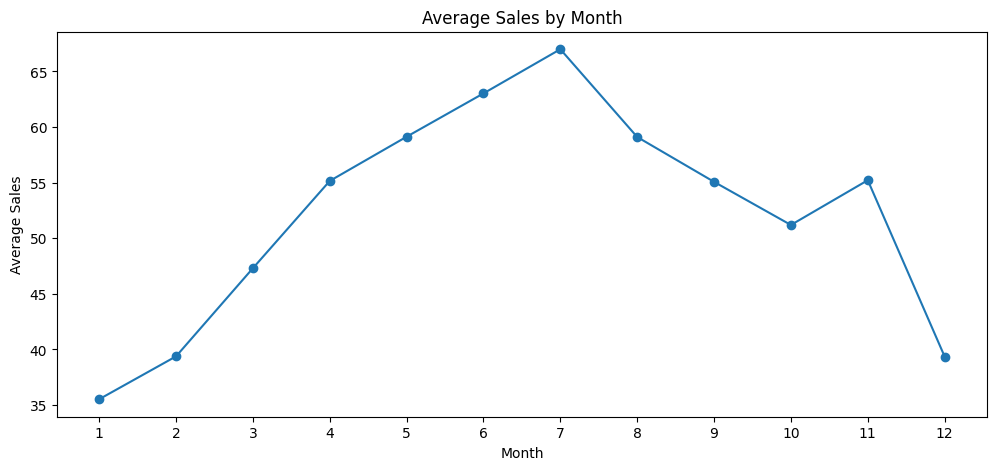

In [ ]:
df_eda = df.copy()
df_eda["year"] = df_eda["date"].dt.year
df_eda["month"] = df_eda["date"].dt.month
df_eda["dayofweek"] = df_eda["date"].dt.day_name()

monthly_sales = df_eda.groupby("month", as_index=False)["sales"].mean()

plt.plot(monthly_sales["month"], monthly_sales["sales"], marker="o")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.show()

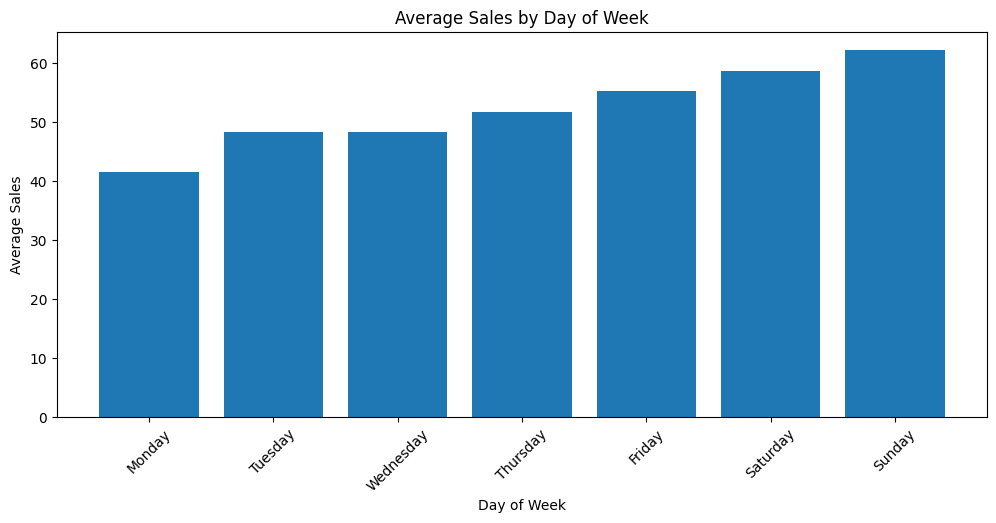

In [ ]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = df_eda.groupby("dayofweek", as_index=False)["sales"].mean()
weekday_sales["dayofweek"] = pd.Categorical(weekday_sales["dayofweek"], categories=weekday_order, ordered=True)
weekday_sales = weekday_sales.sort_values("dayofweek")

plt.bar(weekday_sales["dayofweek"].astype(str), weekday_sales["sales"])
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

## 6. Feature Engineering

We create features from:
- calendar/date,
- past sales lags,
- rolling averages,
- store and item historical demand.

Important: Lag and rolling features must be calculated within each `store-item` group to avoid mixing products.

In [ ]:
def create_features(data):
    data = data.copy()
    data = data.sort_values(["store", "item", "date"])

    # Date features
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["dayofweek"] = data["date"].dt.dayofweek
    data["dayofyear"] = data["date"].dt.dayofyear
    data["weekofyear"] = data["date"].dt.isocalendar().week.astype(int)
    data["quarter"] = data["date"].dt.quarter
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

    # Lag features by store-item
    group_cols = ["store", "item"]
    for lag in [1, 7, 14, 28, 30]:
        data[f"sales_lag_{lag}"] = data.groupby(group_cols)["sales"].shift(lag)

    # Rolling mean features by store-item
    for window in [7, 14, 28, 30]:
        data[f"rolling_mean_{window}"] = (
            data.groupby(group_cols)["sales"]
            .shift(1)
            .rolling(window=window)
            .mean()
        )

    # Rolling std features by store-item
    for window in [7, 14, 30]:
        data[f"rolling_std_{window}"] = (
            data.groupby(group_cols)["sales"]
            .shift(1)
            .rolling(window=window)
            .std()
        )

    return data

feature_df = create_features(df)
feature_df.head()

,date,store,item,sales,year,month,day,dayofweek,dayofyear,weekofyear,quarter,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_std_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,2,1,1,0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,3,1,1,0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,4,1,1,0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,5,1,1,1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
feature_df.isna().sum().sort_values(ascending=False).head(15)

,0
rolling_std_30,15000
sales_lag_30,15000
rolling_mean_30,15000
sales_lag_28,14000
rolling_mean_28,14000
rolling_std_14,7000
sales_lag_14,7000
rolling_mean_14,7000
rolling_mean_7,3500
sales_lag_7,3500


In [ ]:
# Drop rows where lag/rolling features are missing
model_df = feature_df.dropna().reset_index(drop=True)

print("Original rows:", len(df))
print("Rows after feature engineering:", len(model_df))
model_df.head()

Original rows: 913000
Rows after feature engineering: 898000


,date,store,item,sales,year,month,day,dayofweek,dayofyear,weekofyear,quarter,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_std_30
0,2013-01-31,1,1,13,2013,1,31,3,31,5,1,0,9.0,8.0,16.0,14.0,13.0,10.285714,10.857143,10.392857,10.500000,2.751623,3.759238,3.104502
1,2013-02-01,1,1,11,2013,2,1,4,32,5,1,0,13.0,14.0,7.0,13.0,11.0,11.000000,10.642857,10.357143,10.500000,2.708013,3.521519,3.104502
2,2013-02-02,1,1,21,2013,2,2,5,33,5,1,1,11.0,12.0,18.0,10.0,14.0,10.571429,10.928571,10.285714,10.500000,2.370453,3.361874,3.104502
3,2013-02-03,1,1,15,2013,2,3,6,34,5,1,1,21.0,12.0,15.0,12.0,13.0,11.857143,11.142857,10.678571,10.733333,4.634241,3.899845,3.600128
4,2013-02-04,1,1,14,2013,2,4,0,35,6,1,0,15.0,11.0,8.0,10.0,10.0,12.285714,11.142857,10.785714,10.800000,4.785892,3.899845,3.661543


## 7. Train/Test Split

Because this is forecasting, do **not** randomly split.

We train on the past and test on the future.

Here we use the last 90 days as test data.

In [ ]:
last_date = model_df["date"].max()
test_start_date = last_date - pd.Timedelta(days=90)

train_df = model_df[model_df["date"] < test_start_date].copy()

test_df = model_df[model_df["date"] >= test_start_date].copy()

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train date range: 2013-01-31 00:00:00 to 2017-10-01 00:00:00
Test date range: 2017-10-02 00:00:00 to 2017-12-31 00:00:00
Train rows: 852500
Test rows: 45500


In [ ]:
test_df2 = pd.read_csv("/content/drive/MyDrive/Datasets/demand-forecasting/data/train.csv")

df = pd.read_csv(DATA_PATH)
df.head()


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
target = "sales"
ignore_cols = ["date", target]
features = [col for col in model_df.columns if col not in ignore_cols]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

features

['store',
 'item',
 'year',
 'month',
 'day',
 'dayofweek',
 'dayofyear',
 'weekofyear',
 'quarter',
 'is_weekend',
 'sales_lag_1',
 'sales_lag_7',
 'sales_lag_14',
 'sales_lag_28',
 'sales_lag_30',
 'rolling_mean_7',
 'rolling_mean_14',
 'rolling_mean_28',
 'rolling_mean_30',
 'rolling_std_7',
 'rolling_std_14',
 'rolling_std_30']

## 8. Evaluation Functions

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

## 9. Baseline Model

A simple baseline predicts demand using the 7-day lag.

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    # The 'squared' parameter was removed in scikit-learn version 0.22+.
    # To get RMSE, calculate MSE and then take the square root.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

baseline_pred = test_df["sales_lag_7"]
baseline_results = evaluate_model("Baseline: sales_lag_7", y_test, baseline_pred)
baseline_results

{'model': 'Baseline: sales_lag_7',
 'MAE': 9.061252747252746,
 'RMSE': np.float64(12.035457687941982),
 'MAPE_%': np.float64(19.93325891366549),
 'R2': 0.8204466000185279}

## 10. Model 1 - Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_pred = np.maximum(lr_pred, 0)

lr_results = evaluate_model("Linear Regression", y_test, lr_pred)
lr_results

{'model': 'Linear Regression',
 'MAE': 7.036555811985957,
 'RMSE': np.float64(9.249344691213496),
 'MAPE_%': np.float64(15.449028483854054),
 'R2': 0.893954964641656}

## 11. Model 2 - Random Forest

Random Forest captures non-linear demand patterns.

In [34]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_results = evaluate_model("Random Forest", y_test, rf_pred)
rf_results

{'model': 'Random Forest',
 'MAE': 6.1740886660905,
 'RMSE': np.float64(8.083551200885802),
 'MAPE_%': np.float64(13.504775864684055),
 'R2': 0.9190022790230264}

## 12. Model 3 - XGBoost

XGBoost is commonly used for tabular forecasting problems.

In [32]:
xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_pred = np.maximum(xgb_pred, 0)

xgb_results = evaluate_model("XGBoost", y_test, xgb_pred)
xgb_results


{'model': 'XGBoost',
 'MAE': 5.9248151779174805,
 'RMSE': np.float64(7.671515741890658),
 'MAPE_%': np.float64(13.044212206695663),
 'R2': 0.9270491003990173}

## 13. Compare Model Performance

In [35]:
results = [baseline_results, lr_results, rf_results]
if xgb_results is not None:
    results.append(xgb_results)

results_df = pd.DataFrame(results).sort_values("MAPE_%")
results_df

,model,MAE,RMSE,MAPE_%,R2
3,XGBoost,5.924815,7.671516,13.044212,0.927049
2,Random Forest,6.174089,8.083551,13.504776,0.919002
1,Linear Regression,7.036556,9.249345,15.449028,0.893955
0,Baseline: sales_lag_7,9.061253,12.035458,19.933259,0.820447


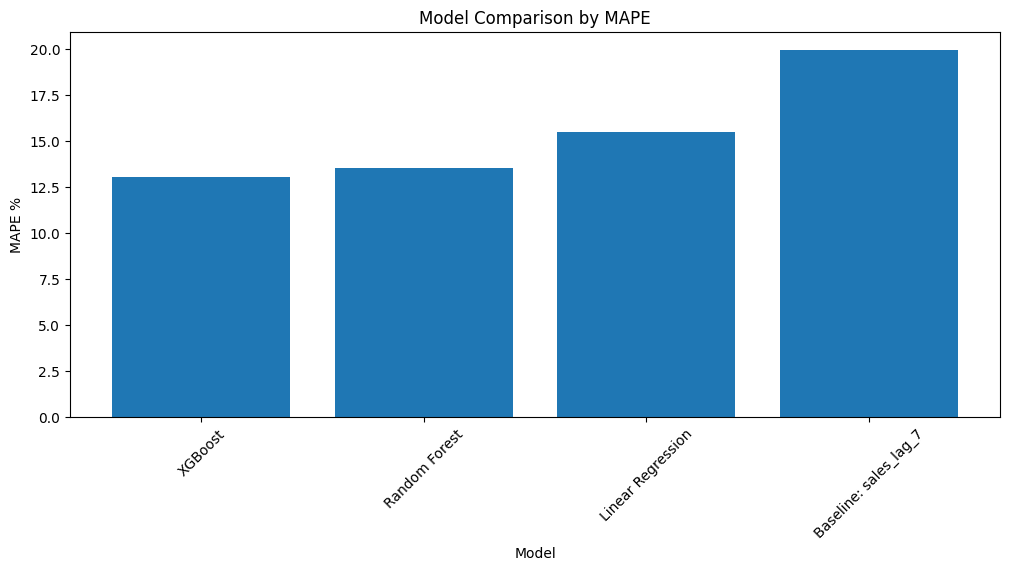

In [36]:
plt.bar(results_df["model"], results_df["MAPE_%"])
plt.title("Model Comparison by MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE %")
plt.xticks(rotation=45)
plt.show()

## 14. Actual vs Predicted Plot

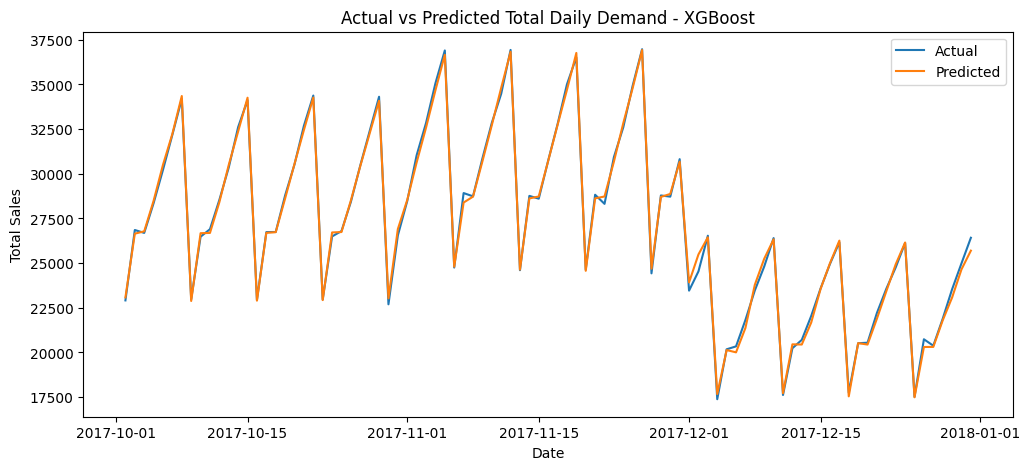

,date,actual_sales,predicted_sales
0,2017-10-02,22913,23082.451172
1,2017-10-03,26854,26648.519531
2,2017-10-04,26691,26779.769531
3,2017-10-05,28357,28489.982422
4,2017-10-06,30225,30506.669922


In [37]:
# Choose best available model prediction
if xgb_pred is not None:
    best_model_name = "XGBoost"
    test_df["prediction"] = xgb_pred
elif rf_pred is not None:
    best_model_name = "Random Forest"
    test_df["prediction"] = rf_pred
else:
    best_model_name = "Linear Regression"
    test_df["prediction"] = lr_pred

# Aggregate actual and predicted sales by date
actual_vs_pred = test_df.groupby("date", as_index=False).agg(
    actual_sales=("sales", "sum"),
    predicted_sales=("prediction", "sum")
)

plt.plot(actual_vs_pred["date"], actual_vs_pred["actual_sales"], label="Actual")
plt.plot(actual_vs_pred["date"], actual_vs_pred["predicted_sales"], label="Predicted")
plt.title(f"Actual vs Predicted Total Daily Demand - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

actual_vs_pred.head()

## 15. Feature Importance

In [38]:
if best_model_name == "XGBoost":
    importances = xgb.feature_importances_
elif best_model_name == "Random Forest":
    importances = rf.feature_importances_
else:
    importances = np.abs(lr.coef_)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
16,rolling_mean_14,0.342084
15,rolling_mean_7,0.280992
11,sales_lag_7,0.216586
12,sales_lag_14,0.033864
9,is_weekend,0.030204
17,rolling_mean_28,0.025046
5,dayofweek,0.021329
18,rolling_mean_30,0.011581
13,sales_lag_28,0.010381
10,sales_lag_1,0.009363


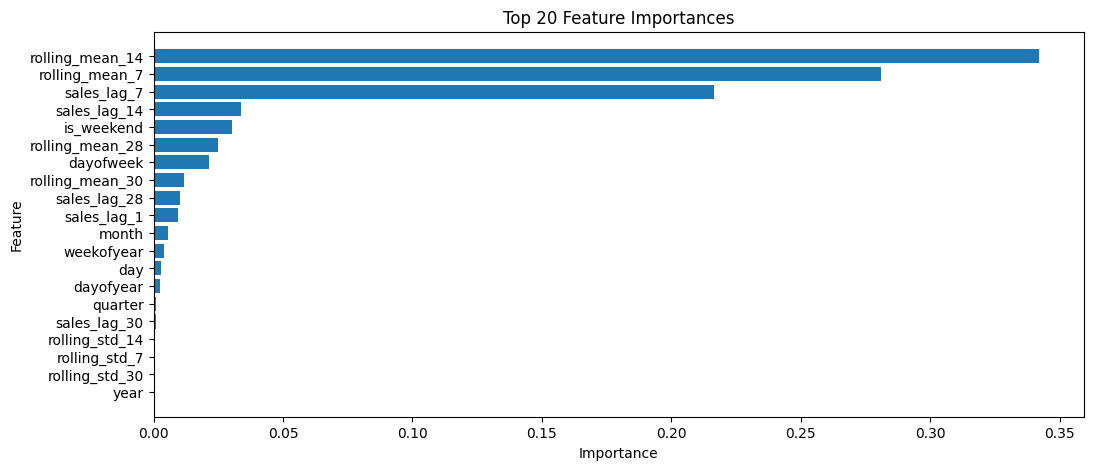

In [39]:
top_imp = importance_df.head(20)
plt.barh(top_imp["feature"][::-1], top_imp["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 16. Error Analysis

Find where the model performs poorly.

In [41]:
test_df["absolute_error"] = np.abs(test_df["sales"] - test_df["prediction"])
test_df["absolute_percentage_error"] = test_df["absolute_error"] / test_df["sales"].replace(0, np.nan) * 100

test_df.sort_values("absolute_error", ascending=False).head(10)[[
    "date", "store", "item", "sales", "prediction", "absolute_error", "absolute_percentage_error"
]]

,date,store,item,sales,prediction,absolute_error,absolute_percentage_error
777594,2017-10-19,9,33,117,78.104271,38.895729,33.244213
247786,2017-10-31,3,38,62,99.522270,37.522270,60.519791
668075,2017-11-25,8,22,165,128.400848,36.599152,22.181304
678857,2017-12-01,8,28,70,105.985504,35.985504,51.407863
745330,2017-12-22,9,15,116,80.255432,35.744568,30.814283
651858,2017-10-03,8,13,139,103.296661,35.703339,25.685855
129262,2017-11-12,2,22,113,148.378906,35.378906,31.308767
222702,2017-12-30,3,24,108,72.899483,35.100517,32.500479
222645,2017-11-03,3,24,128,93.275734,34.724266,27.128333
154376,2017-10-13,2,36,150,115.712257,34.287743,22.858495


In [42]:
store_error = test_df.groupby("store", as_index=False).agg(
    actual=("sales", "sum"),
    predicted=("prediction", "sum"),
    mae=("absolute_error", "mean")
)
store_error["error_pct"] = np.abs(store_error["actual"] - store_error["predicted"]) / store_error["actual"] * 100
store_error.sort_values("error_pct", ascending=False)

,store,actual,predicted,mae,error_pct
7,8,305512,304361.968750,6.697732,0.376428
1,2,318768,317670.781250,6.758347,0.344206
2,3,282515,281712.281250,6.351134,0.284133
4,5,188423,188655.625000,5.206661,0.123459
9,10,277877,277648.218750,6.186009,0.082332
5,6,188421,188570.062500,5.167671,0.079111
6,7,172722,172823.640625,4.904288,0.058846
8,9,261716,261755.078125,6.187618,0.014932
0,1,225009,224985.437500,5.636112,0.010472
3,4,260359,260333.109375,6.152577,0.009944


## 17. Forecast Next 30 Days

For true future forecasting, we need to create future dates and recursively update lag features.

To keep this beginner-friendly, this section forecasts future sales using the trained model and recent historical data.

Note: For production forecasting, you would improve this with:
- recursive lag updates,
- holiday features,
- promotions,
- weather,
- price changes,
- inventory constraints.

In [52]:
test_df2 = pd.read_csv("/content/drive/MyDrive/Datasets/demand-forecasting/data/test.csv")

test_df2.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [56]:
# Simple future forecasting approach:

# Ensure 'date' columns are in datetime format before concatenating
df['date'] = pd.to_datetime(df['date'])
test_df2['date'] = pd.to_datetime(test_df2['date'])

combined = pd.concat([df, test_df2.assign(sales=np.nan)], ignore_index=True)
combined = combined.sort_values(["store", "item", "date"]).reset_index(drop=True)

future_feature_df = create_features(combined)
future_rows = future_feature_df[future_feature_df["sales"].isna()].copy()

# Fill remaining missing rolling/lag values with recent medians if necessary
X_future = future_rows[features].copy()
X_future = X_future.fillna(X_train.median(numeric_only=True))

if best_model_name == "XGBoost":
    future_rows["forecasted_sales"] = np.maximum(xgb.predict(X_future), 0)
elif best_model_name == "Random Forest":
    future_rows["forecasted_sales"] = np.maximum(rf.predict(X_future), 0)
else:
    future_rows["forecasted_sales"] = np.maximum(lr.predict(X_future), 0)

future_rows[["date", "store", "item", "forecasted_sales"]].head()

,date,store,item,forecasted_sales
1826,2018-01-01,1,1,12.138213
1827,2018-01-02,1,1,41.563709
1828,2018-01-03,1,1,41.285500
1829,2018-01-04,1,1,45.130962
1830,2018-01-05,1,1,47.958504


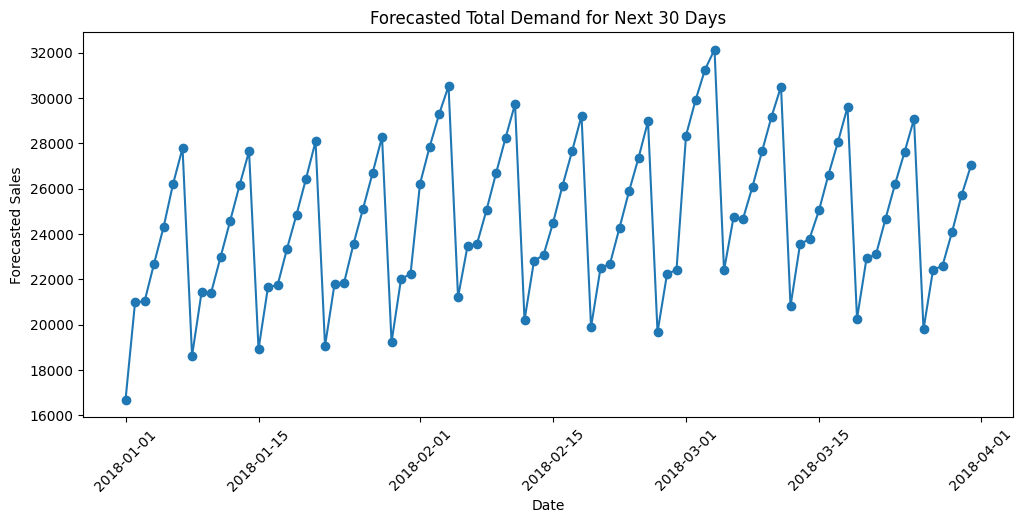

,date,forecasted_sales
0,2018-01-01,16699.328125
1,2018-01-02,20989.746094
2,2018-01-03,21026.607422
3,2018-01-04,22690.216797
4,2018-01-05,24299.693359
...,...,...
85,2018-03-27,22413.607422
86,2018-03-28,22601.345703
87,2018-03-29,24080.892578
88,2018-03-30,25697.621094


In [57]:
daily_forecast = future_rows.groupby("date", as_index=False)["forecasted_sales"].sum()

plt.plot(daily_forecast["date"], daily_forecast["forecasted_sales"], marker="o")
plt.title("Forecasted Total Demand for Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=45)
plt.show()

daily_forecast

## 18. Save Predictions

This creates output files you can use in a portfolio or dashboard.

In [58]:
test_predictions = test_df[["date", "store", "item", "sales", "prediction", "absolute_error", "absolute_percentage_error"]]
future_predictions = future_rows[["date", "store", "item", "forecasted_sales"]]

test_predictions.to_csv("test_predictions.csv", index=False)
future_predictions.to_csv("future_30_day_forecast.csv", index=False)

print("Saved:")
print("test_predictions.csv")
print("future_30_day_forecast.csv")

Saved:
test_predictions.csv
future_30_day_forecast.csv
